# 04. Results Analysis

03·05에서 저장된 예측(`artifacts/predictions/`)을 불러와
subgroup·오분류·시퀀스 패턴 분석을 수행한다.

분석 항목:
1. Subgroup AUC (시퀀스 길이 / 아이템 인기도 / 유저 활동량)
2. 오분류 피처 분포 (FP/FN 분석)
3. 시퀀스 패턴 분석 (target 존재 여부, 반복도 등)
4. 모델 간 예측 상관

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, log_loss

_HERE = Path.cwd()
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))
from utils import nb_utils as U
U.add_fuxictr_to_path()

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 11})

## 1. 스위치 & 데이터 로드

In [2]:
DATASET_ID = 'AmazonElectronics_x1'

# --- 시퀀스·타겟 필드명 (데이터셋별로 교체) ---
SEQ_FIELD   = 'item_history'   # 시퀀스 피처 컬럼
TARGET_ITEM = 'item_id'        # 타겟 아이템 컬럼
CATE_FIELD  = 'cate_id'        # 카테고리 컬럼 (없으면 None)
SEQ_SEP     = '^'              # 시퀀스 구분자

runs_df = U.list_runs(DATASET_ID)
print(f'총 {len(runs_df)} runs')
runs_df[['model','run_id','metric.valid_AUC','metric.test_AUC']].head(20)

총 8 runs


,model,run_id,metric.valid_AUC,metric.test_AUC
0,DIN,20260416-121524_DIN_AmazonElectronics_x1_s2026,0.864903,0.852022
1,DIN,20260416-121659_DIN_AmazonElectronics_x1_s2027,0.862924,0.845535
2,DIN,tune_t000_s2026,0.852111,0.836035
3,DIN,tune_t001_s2026,0.855176,0.839740
4,DIN,tune_t002_s2026,0.863546,0.849563
5,DIN,tune_t003_s2026,0.857037,0.834420
6,DIN,tune_t004_s2026,0.854014,0.835699
7,MyModel_v1,20260416-122945_MyModel_v1_AmazonElectronics_x...,0.868228,0.851477


In [3]:
# 예측 로드: {(model, run_id): DataFrame}
all_preds = U.load_predictions(DATASET_ID)
print(f'예측 파일 {len(all_preds)}개 로드')
for (m, r), df in list(all_preds.items())[:5]:
    print(f'  {m}/{r}: {len(df):,} rows, cols={list(df.columns)[:6]}')

예측 파일 3개 로드
  DIN/20260416-121524_DIN_AmazonElectronics_x1_s2026: 384,806 rows, cols=['user_id', 'item_id', 'cate_id', 'item_history', 'cate_history', 'y_true']
  DIN/20260416-121659_DIN_AmazonElectronics_x1_s2027: 384,806 rows, cols=['user_id', 'item_id', 'cate_id', 'item_history', 'cate_history', 'y_true']
  MyModel_v1/20260416-122945_MyModel_v1_AmazonElectronics_x1_s2026: 384,806 rows, cols=['user_id', 'item_id', 'cate_id', 'item_history', 'cate_history', 'y_true']


In [4]:
# train 데이터에서 아이템 인기도 / 유저 활동량 집계
ds_cfg = U.load_dataset_runtime(DATASET_ID)
train_df = pd.read_parquet(ds_cfg['train_data'])
test_df  = pd.read_parquet(ds_cfg['test_data'])

item_pop = train_df[TARGET_ITEM].value_counts().rename('item_popularity')
print(f'train rows={len(train_df):,}  unique items={len(item_pop):,}')

if 'user_id' in train_df.columns:
    user_act = train_df['user_id'].value_counts().rename('user_activity')
    print(f'unique users={len(user_act):,}')
else:
    user_act = None
    print('user_id not found — user activity analysis skipped')

train rows=2,347,550  unique items=63,001
unique users=173,163


## 2. 유틸 함수

In [5]:
def seq_to_tokens(val, sep='^'):
    """Return list[str] tokens from either a sequence string ('a^b^c')
    or a numeric array (numpy/list, 0-padded as FuxiCTR stores it)."""
    if val is None:
        return []
    if isinstance(val, (list, tuple, np.ndarray)):
        return [str(x) for x in val if x != 0 and not (isinstance(x, float) and np.isnan(x))]
    if isinstance(val, float) and np.isnan(val):
        return []
    s = str(val)
    if not s or s.lower() == 'nan':
        return []
    return [t for t in s.split(sep) if t]


def subgroup_auc(pred_df, group_col, bins=None, labels=None):
    """group_col 별 AUC/logloss 계산."""
    if bins is not None:
        pred_df = pred_df.copy()
        pred_df['_grp'] = pd.cut(pred_df[group_col], bins=bins, labels=labels)
        group_col = '_grp'
    rows = []
    for g, sub in pred_df.groupby(group_col, observed=True):
        if sub['y_true'].nunique() < 2:
            continue
        rows.append({
            'group': g,
            'count': len(sub),
            'AUC': roc_auc_score(sub['y_true'], sub['y_pred']),
            'logloss': log_loss(sub['y_true'], np.clip(sub['y_pred'], 1e-7, 1-1e-7)),
        })
    return pd.DataFrame(rows)


def seq_length(series, sep='^'):
    """시퀀스 토큰 수 (배열/문자열 모두 처리)."""
    return series.apply(lambda v: len(seq_to_tokens(v, sep)))


def plot_subgroup_comparison(results_dict, ylabel='AUC', title=''):
    """여러 모델의 subgroup 결과를 라인 차트로 비교."""
    fig, ax = plt.subplots()
    for label, df in results_dict.items():
        ax.plot(df['group'].astype(str), df[ylabel], marker='o', label=label)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 3. Subgroup AUC 분석

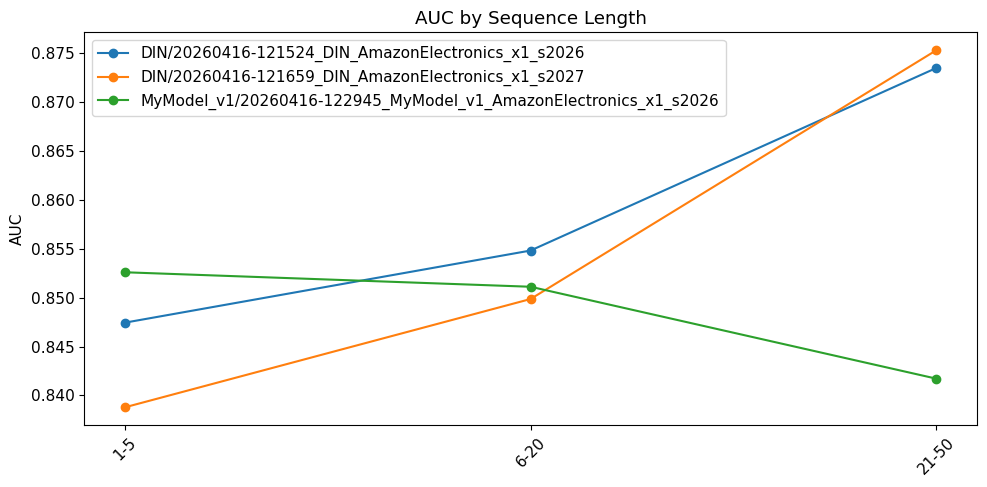

In [6]:
# --- 3-1. 시퀀스 길이 bin별 AUC ---
seq_len_bins = [0, 1, 5, 20, 50, 9999]
seq_len_labels = ['0', '1-5', '6-20', '21-50', '50+']

seq_results = {}
for (model, run_id), pdf in all_preds.items():
    if SEQ_FIELD not in pdf.columns:
        print(f'  skip {model}/{run_id}: {SEQ_FIELD} not in preds columns')
        continue
    pdf = pdf.copy()
    pdf['seq_len'] = seq_length(pdf[SEQ_FIELD], SEQ_SEP)
    res = subgroup_auc(pdf, 'seq_len', bins=seq_len_bins, labels=seq_len_labels)
    seq_results[f'{model}/{run_id}'] = res

if seq_results:
    plot_subgroup_comparison(seq_results, ylabel='AUC', title='AUC by Sequence Length')
else:
    print(f'{SEQ_FIELD} not found in any prediction files')

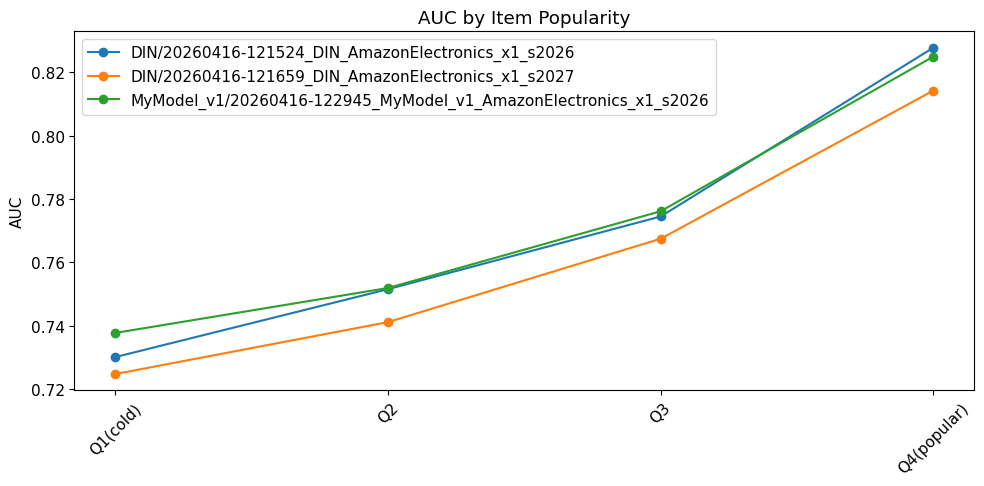

In [7]:
# --- 3-2. 아이템 인기도 bin별 AUC ---
pop_bins = [0] + item_pop.quantile([0.25, 0.5, 0.75]).tolist() + [item_pop.max() + 1]
pop_labels = ['Q1(cold)', 'Q2', 'Q3', 'Q4(popular)']

pop_results = {}
for (model, run_id), pdf in all_preds.items():
    if TARGET_ITEM not in pdf.columns:
        continue
    pdf = pdf.copy()
    pdf['item_pop'] = pdf[TARGET_ITEM].map(item_pop).fillna(0)
    res = subgroup_auc(pdf, 'item_pop', bins=pop_bins, labels=pop_labels)
    pop_results[f'{model}/{run_id}'] = res

if pop_results:
    plot_subgroup_comparison(pop_results, ylabel='AUC', title='AUC by Item Popularity')
else:
    print(f'{TARGET_ITEM} not found in prediction files')

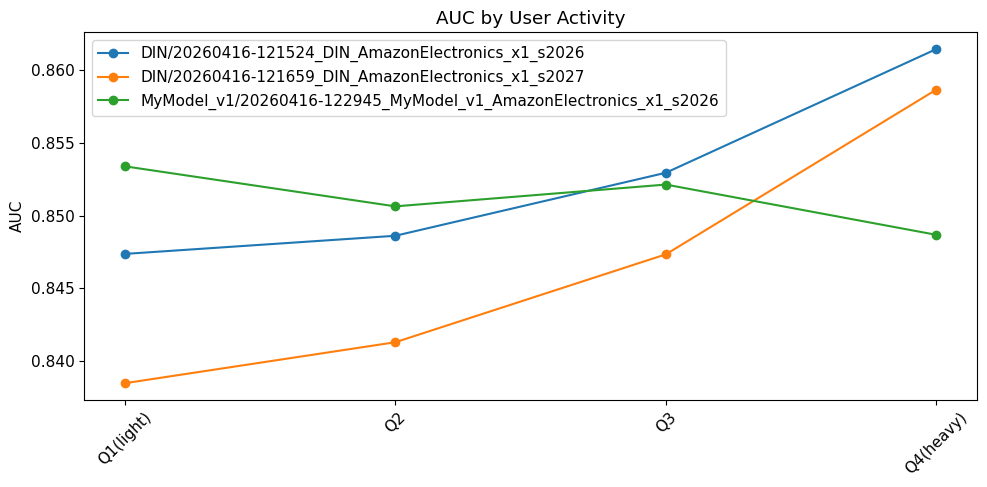

In [8]:
# --- 3-3. 유저 활동량 bin별 AUC ---
if user_act is not None:
    act_bins = [0] + user_act.quantile([0.25, 0.5, 0.75]).tolist() + [user_act.max() + 1]
    act_labels = ['Q1(light)', 'Q2', 'Q3', 'Q4(heavy)']

    act_results = {}
    for (model, run_id), pdf in all_preds.items():
        if 'user_id' not in pdf.columns:
            continue
        pdf = pdf.copy()
        pdf['user_act'] = pdf['user_id'].map(user_act).fillna(0)
        res = subgroup_auc(pdf, 'user_act', bins=act_bins, labels=act_labels)
        act_results[f'{model}/{run_id}'] = res

    if act_results:
        plot_subgroup_comparison(act_results, ylabel='AUC', title='AUC by User Activity')
    else:
        print('user_id not in prediction files')
else:
    print('user activity analysis skipped')

## 4. 오분류 피처 분포

In [9]:
# 대표 모델 하나 선택 (첫 번째 예측 파일)
rep_key = list(all_preds.keys())[0]
rep_df = all_preds[rep_key].copy()
print(f'분석 대상: {rep_key[0]}/{rep_key[1]}, {len(rep_df):,} rows')

# FN: label=1이지만 예측값 하위 10%
pos = rep_df[rep_df['y_true'] == 1]
fn_threshold = pos['y_pred'].quantile(0.1)
fn_df = pos[pos['y_pred'] <= fn_threshold]

# FP: label=0이지만 예측값 상위 10%
neg = rep_df[rep_df['y_true'] == 0]
fp_threshold = neg['y_pred'].quantile(0.9)
fp_df = neg[neg['y_pred'] >= fp_threshold]

print(f'FN (missed positives): {len(fn_df):,}  (threshold={fn_threshold:.4f})')
print(f'FP (false alarms):     {len(fp_df):,}  (threshold={fp_threshold:.4f})')

분석 대상: DIN/20260416-121524_DIN_AmazonElectronics_x1_s2026, 384,806 rows
FN (missed positives): 19,241  (threshold=0.2162)
FP (false alarms):     19,241  (threshold=0.6123)


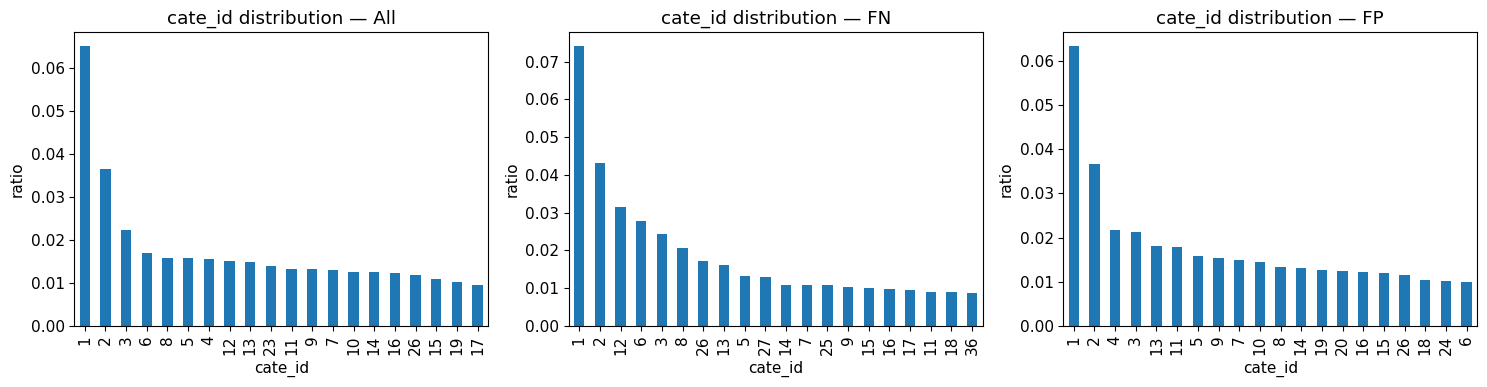

In [10]:
# 카테고리 피처의 FN/FP vs 전체 분포 비교
cat_col = CATE_FIELD if CATE_FIELD and CATE_FIELD in rep_df.columns else None
if cat_col:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (label, subset) in zip(axes, [('All', rep_df), ('FN', fn_df), ('FP', fp_df)]):
        top20 = subset[cat_col].value_counts(normalize=True).head(20)
        top20.plot.bar(ax=ax, title=f'{cat_col} distribution — {label}')
        ax.set_ylabel('ratio')
    plt.tight_layout()
    plt.show()
else:
    print(f'CATE_FIELD={CATE_FIELD} not found in predictions — skip category distribution')

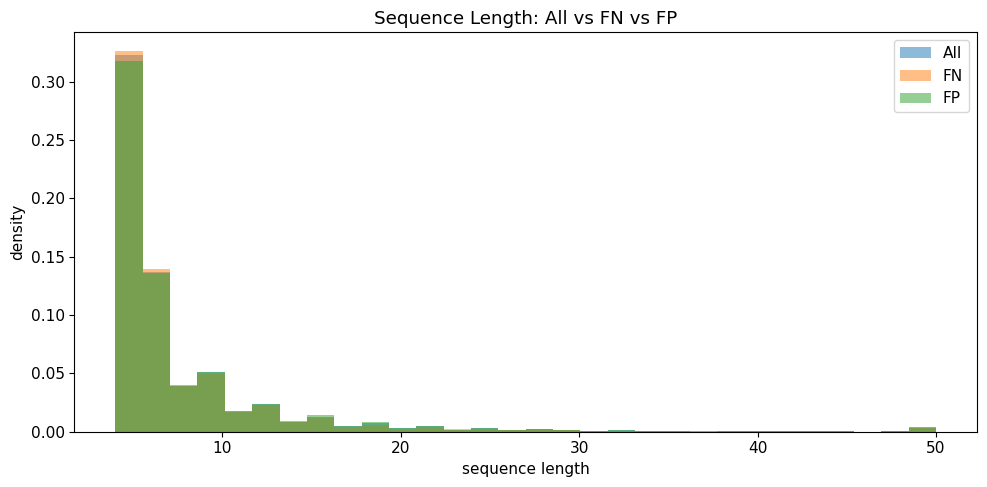

In [11]:
# 시퀀스 길이 분포 — FN/FP vs 전체
if SEQ_FIELD in rep_df.columns:
    rep_df['_seq_len'] = seq_length(rep_df[SEQ_FIELD], SEQ_SEP)
    fn_df_sl = rep_df.loc[fn_df.index, '_seq_len'] if len(fn_df) else pd.Series(dtype=int)
    fp_df_sl = rep_df.loc[fp_df.index, '_seq_len'] if len(fp_df) else pd.Series(dtype=int)

    fig, ax = plt.subplots()
    for label, s in [('All', rep_df['_seq_len']), ('FN', fn_df_sl), ('FP', fp_df_sl)]:
        if len(s) > 0:
            ax.hist(s, bins=30, alpha=0.5, density=True, label=label)
    ax.set_xlabel('sequence length')
    ax.set_ylabel('density')
    ax.set_title('Sequence Length: All vs FN vs FP')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'{SEQ_FIELD} not in predictions')

## 5. 시퀀스 패턴 분석

In [12]:
if SEQ_FIELD in rep_df.columns and TARGET_ITEM in rep_df.columns:
    seq_tokens_col = rep_df[SEQ_FIELD].apply(lambda v: seq_to_tokens(v, SEQ_SEP))
    target_str = rep_df[TARGET_ITEM].astype(str)
    rep_df['target_in_history'] = [t in toks for t, toks in zip(target_str, seq_tokens_col)]

    for flag_val, label in [(True, 'target IN history'), (False, 'target NOT in history')]:
        sub = rep_df[rep_df['target_in_history'] == flag_val]
        if sub['y_true'].nunique() >= 2:
            auc = roc_auc_score(sub['y_true'], sub['y_pred'])
            ctr = sub['y_true'].mean()
            print(f'{label}: n={len(sub):,}  CTR={ctr:.4f}  AUC={auc:.4f}')
        else:
            print(f'{label}: n={len(sub):,}  (single class, AUC undefined)')
else:
    print('target_in_history analysis skipped')

target IN history: n=0  (single class, AUC undefined)
target NOT in history: n=384,806  CTR=0.5000  AUC=0.8520


In [13]:
# 시퀀스 반복도 (unique tokens / length)
if SEQ_FIELD in rep_df.columns:
    def _diversity(v):
        toks = seq_to_tokens(v, SEQ_SEP)
        return len(set(toks)) / len(toks) if toks else 0.0

    rep_df['seq_diversity'] = rep_df[SEQ_FIELD].apply(_diversity)

    div_bins = [0, 0.3, 0.6, 0.8, 1.01]
    div_labels = ['0-0.3', '0.3-0.6', '0.6-0.8', '0.8-1.0']
    res = subgroup_auc(rep_df, 'seq_diversity', bins=div_bins, labels=div_labels)
    print('AUC by sequence diversity (unique/length):')
    print(res.to_string(index=False))
else:
    print('seq_diversity analysis skipped')

AUC by sequence diversity (unique/length):
  group  count      AUC  logloss
0.8-1.0 384806 0.852022 0.482683


In [14]:
# 마지막 토큰 == target 여부별 CTR
if SEQ_FIELD in rep_df.columns and TARGET_ITEM in rep_df.columns:
    seq_tokens_col = rep_df[SEQ_FIELD].apply(lambda v: seq_to_tokens(v, SEQ_SEP))
    target_str = rep_df[TARGET_ITEM].astype(str)
    rep_df['last_is_target'] = [
        (bool(toks) and toks[-1] == t) for t, toks in zip(target_str, seq_tokens_col)
    ]
    for flag_val in [True, False]:
        sub = rep_df[rep_df['last_is_target'] == flag_val]
        ctr = sub['y_true'].mean() if len(sub) else 0
        print(f'last_is_target={flag_val}: n={len(sub):,}  CTR={ctr:.4f}')
else:
    print('last_token_match analysis skipped')

last_is_target=True: n=0  CTR=0.0000
last_is_target=False: n=384,806  CTR=0.5000


## 6. 모델 간 예측 상관

Prediction correlation matrix:
                                                                   DIN__20260416-121524_DIN_AmazonElectronics_x1_s2026  DIN__20260416-121659_DIN_AmazonElectronics_x1_s2027  MyModel_v1__20260416-122945_MyModel_v1_AmazonElectronics_x1_s2026
DIN__20260416-121524_DIN_AmazonElectronics_x1_s2026                                                             1.0000                                               0.9236                                                             0.9091
DIN__20260416-121659_DIN_AmazonElectronics_x1_s2027                                                             0.9236                                               1.0000                                                             0.8983
MyModel_v1__20260416-122945_MyModel_v1_AmazonElectronics_x1_s2026                                               0.9091                                               0.8983                                                             1.0000


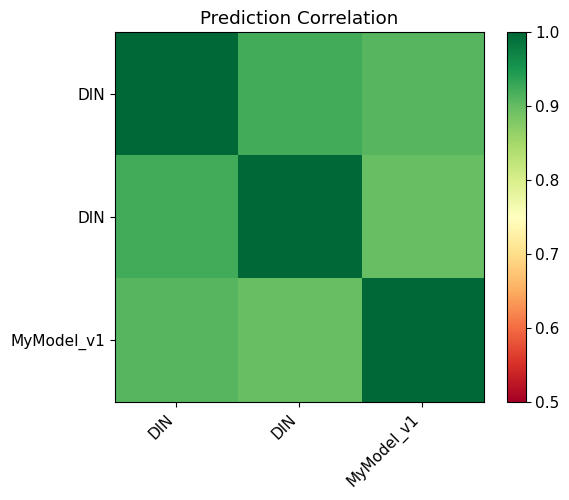

In [15]:
if len(all_preds) >= 2:
    pred_wide = pd.DataFrame()
    for (model, run_id), pdf in all_preds.items():
        col_name = f'{model}__{run_id}'
        pred_wide[col_name] = pdf['y_pred'].values[:len(pred_wide)] if len(pred_wide) else pdf['y_pred'].values
        if len(pred_wide.columns) == 1:
            pred_wide = pred_wide.reindex(range(len(pdf)))
            pred_wide[col_name] = pdf['y_pred'].values

    corr = pred_wide.corr()
    print('Prediction correlation matrix:')
    print(corr.round(4).to_string())

    fig, ax = plt.subplots(figsize=(max(6, len(corr)*1.5), max(5, len(corr)*1.2)))
    im = ax.imshow(corr.values, cmap='RdYlGn', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(corr)))
    ax.set_yticks(range(len(corr)))
    short_labels = [c.split('__')[0] for c in corr.columns]
    ax.set_xticklabels(short_labels, rotation=45, ha='right')
    ax.set_yticklabels(short_labels)
    plt.colorbar(im, ax=ax)
    ax.set_title('Prediction Correlation')
    plt.tight_layout()
    plt.show()
else:
    print('Need >=2 prediction files for correlation analysis')

## 7. (선택) 분석 결과 저장

In [16]:
# 06_Results_viz에서 재사용하려면 저장
# analysis_dir = U.ARTIFACT_ROOT / 'analysis' / DATASET_ID
# analysis_dir.mkdir(parents=True, exist_ok=True)
# for key, df in seq_results.items():
#     safe_name = key.replace('/', '_')
#     df.to_parquet(analysis_dir / f'subgroup_seqlen_{safe_name}.parquet', index=False)
# print(f'saved to {analysis_dir}')